In [5]:
!pip install torch torchvision torchtext

   ---------------------------------------- 0.0/1.9 MB ? eta -:--:--
   - -------------------------------------- 0.1/1.9 MB 1.7 MB/s eta 0:00:02
   --------------------- ------------------ 1.0/1.9 MB 13.0 MB/s eta 0:00:01
   ---------------------------------------- 1.9/1.9 MB 20.6 MB/s eta 0:00:00


In [2]:
import torch

In [3]:
x=3
w=torch.tensor(1.0,requires_grad=True)
z=w*x
out=z**2
out.backward()
print('out을 w로 미분한 값',w.grad)

out을 w로 미분한 값 tensor(18.)


# 텐서 

In [4]:
import numpy as np
import torch
data=np.array([[1,2,3],[4,5,6],[7,8,9]])
x=torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
x.size()
#x.shape
x.ndimension()
x.shape

torch.Size([3, 3])

In [5]:
x=torch.tensor([[1,2,3],[4,5,6],[7,8,9]])
x=torch.unsqueeze(x,1)
x.shape

torch.Size([3, 1, 3])

In [6]:
x=torch.squeeze(x)
x.shape

torch.Size([3, 3])

In [8]:
x.view(3,4)

RuntimeError: shape '[3, 4]' is invalid for input of size 9

In [9]:
x.reshape(3,4)

RuntimeError: shape '[3, 4]' is invalid for input of size 9

In [10]:
x+np.array([1,1,1])

tensor([[ 2,  3,  4],
        [ 5,  6,  7],
        [ 8,  9, 10]])

In [11]:
np.array([1,1,1]).shape

(3,)

In [12]:
w=torch.randn(5,3,dtype=torch.float)
x=torch.tensor([[1.0,2.0],[3.0,4.0],[5.0,6.0]])
w.shape,x.shape

(torch.Size([5, 3]), torch.Size([3, 2]))

In [13]:
b=torch.randn(5,2,dtype=torch.float)
b.shape

torch.Size([5, 2])

In [14]:
wx=torch.mm(w,x)

In [15]:
z=wx+b
z

tensor([[ 5.3650,  5.2511],
        [ 3.8164,  5.1734],
        [13.0798, 17.3274],
        [-7.8964, -7.7070],
        [-5.4673, -4.0207]])

In [16]:
import numpy as np
import torch
from sklearn.datasets import make_blobs

In [17]:
n_dim=2
tr_x,tr_y=make_blobs(n_samples=80,n_features=2,centers=[[1,1],[-1,-1],[1,-1],[-1,1]],shuffle=True,cluster_std=0.3)
tt_x,tt_y=make_blobs(n_samples=20,n_features=2,centers=[[1,1],[-1,-1],[1,-1],[-1,1]],shuffle=True,cluster_std=0.3)

In [18]:
def label_map(y,from_,n):
    ck_y=y.copy()
    for i in from_:
        ck_y[y==i]=n
    return ck_y
tr_y=label_map(tr_y,[0,1],0)
tr_y=label_map(tr_y,[2,3],1)
tt_y=label_map(tt_y,[0,1],0)
tt_y=label_map(tt_y,[2,3],1)

In [19]:
tr_x.shape,tr_y.shape

((80, 2), (80,))

In [20]:
np.unique(tr_y)

array([0, 1])

In [21]:
import matplotlib.pyplot as plt
def v_data(x,y=None,c='r'):
    if y is None:
        y=[None]*len(x)# [None for _ in range(len(x))]
    for ck_x,ck_y in zip(x,y):
        if ck_y is None:
            plt.plot(ck_x[0],ck_x[1],'*',markerfacecolor='none',markeredgecolor=c)
        else:
            plt.plot(ck_x[0],ck_x[1], 'o'+c if ck_y==0 else '+'+c )
        

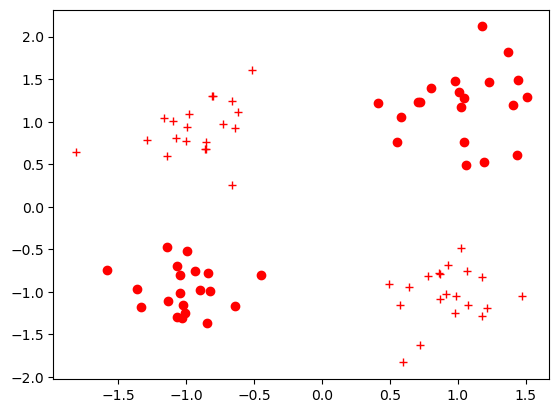

In [22]:
v_data(tr_x,tr_y)
plt.show()

In [23]:
t_tr_x=torch.FloatTensor(tr_x)
t_tt_x=torch.FloatTensor(tt_x)
t_tr_y=torch.FloatTensor(tr_y)
t_tt_y=torch.FloatTensor(tt_y)
t_tr_x.shape,t_tr_y.shape

(torch.Size([80, 2]), torch.Size([80]))

In [24]:
class NeuralNet(torch.nn.Module):
    def __init__(self,input_size,hidden_size):
        super().__init__()
        self.input_size=input_size
        self.hidden_size=hidden_size
        self.l1=torch.nn.Linear(self.input_size,self.hidden_size)
        self.relu=torch.nn.ReLU()
        self.l2=torch.nn.Linear(self.hidden_size,1)
        self.sigmoid=torch.nn.Sigmoid()    
    def forward(self,input_tensor):
        l1=self.l1(input_tensor)
        relu=self.relu(l1)
        l2=self.l2(relu)
        output=self.sigmoid(l2)
        return output

In [25]:
m=NeuralNet(2,5)
criterion=torch.nn.BCELoss()
opt=torch.optim.SGD(m.parameters(),lr=0.03)
epochs=1000

In [26]:
ty=t_tt_y

In [27]:
py=m(t_tt_x)

In [28]:
criterion(ty,py.squeeze())

tensor(49.3379, grad_fn=<BinaryCrossEntropyBackward0>)

In [29]:
test_loss=criterion(py.squeeze(),ty)

In [30]:
test_loss.item()

0.6972892880439758

In [31]:
for epoch in range(epochs):
    m.train()
    opt.zero_grad()
    tr_output=m(t_tr_x)
    tr_loss=criterion(tr_output.squeeze(),t_tr_y)
    if epoch %100==0:
        print(f"epoch:{epoch} loss:{tr_loss.item()}")
    tr_loss.backward()
    opt.step()

epoch:0 loss:0.6936735510826111
epoch:100 loss:0.6415464282035828
epoch:200 loss:0.5793038606643677
epoch:300 loss:0.5113809108734131
epoch:400 loss:0.4456436038017273
epoch:500 loss:0.38077664375305176
epoch:600 loss:0.3125682473182678
epoch:700 loss:0.24251453578472137
epoch:800 loss:0.17860841751098633
epoch:900 loss:0.13158494234085083


In [32]:
m.eval()
py=m(t_tt_x)
ty=t_tt_y
test_loss=criterion(py.squeeze(),ty)
test_loss.item()

0.10756467282772064

In [33]:
m

NeuralNet(
  (l1): Linear(in_features=2, out_features=5, bias=True)
  (relu): ReLU()
  (l2): Linear(in_features=5, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

In [34]:
m.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 1.1004,  1.3593],
                      [-1.1538, -0.1198],
                      [ 0.8862, -1.0229],
                      [-1.1815,  1.2691],
                      [-1.0153,  1.1551]])),
             ('l1.bias',
              tensor([-0.1369,  0.9037, -0.1385, -0.1998, -0.0808])),
             ('l2.weight',
              tensor([[-1.7476, -1.3363,  1.0705,  1.4753,  1.1595]])),
             ('l2.bias', tensor([0.3956]))])

In [35]:
torch.save(m.state_dict(),'m.pt')

In [36]:
n_m=NeuralNet(2,5)
print(n_m.state_dict())
n_m.load_state_dict(torch.load('m.pt'))
print(n_m.state_dict())

OrderedDict([('l1.weight', tensor([[ 0.4684,  0.5584],
        [-0.0028,  0.0396],
        [ 0.6036, -0.1311],
        [ 0.6583,  0.4980],
        [-0.5905, -0.0061]])), ('l1.bias', tensor([-0.5201,  0.0879, -0.1725, -0.1858,  0.1026])), ('l2.weight', tensor([[ 0.3820,  0.3970,  0.3081, -0.1459, -0.2263]])), ('l2.bias', tensor([0.1420]))])
OrderedDict([('l1.weight', tensor([[ 1.1004,  1.3593],
        [-1.1538, -0.1198],
        [ 0.8862, -1.0229],
        [-1.1815,  1.2691],
        [-1.0153,  1.1551]])), ('l1.bias', tensor([-0.1369,  0.9037, -0.1385, -0.1998, -0.0808])), ('l2.weight', tensor([[-1.7476, -1.3363,  1.0705,  1.4753,  1.1595]])), ('l2.bias', tensor([0.3956]))])


In [37]:
n_m.eval()
n_m(torch.FloatTensor([-1,1])).item()

0.9656669497489929

# 위 코드를 참조하여 AND 와 OR 을 만드시오